# Atenciones de urgencia 2024: una vista por columna

Fuente: DEIS-MINSAL (`AtencionesUrgencia2024.zip`, 8,97 millones de filas, 21 columnas).

**Por qué no sirve contar filas.** Cada establecimiento reporta todas las causas todos los días, así que el número de filas por región, causa, semana o fecha es casi igual en todas. Las diferencias reales están en `Total` (atenciones). Por eso aquí cada columna se grafica **ponderada por atenciones**.

**Por qué se filtra.** Las causas son jerárquicas (hay totales, subtotales y detalle en el mismo archivo). Para no contar dos veces:
- Para describir *dónde y cuándo* se atiende, se usa solo la fila `IdCausa == 1` (total de atenciones de urgencia del establecimiento ese día).
- Para describir *por qué* se atiende, se usan solo las causas de detalle.

In [13]:
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

ZIP, CSV = "AtencionesUrgencia2024.zip", "AtencionesUrgencia2024.csv"
EDADES = ["Menores_1", "De_1_a_4", "De_5_a_14", "De_15_a_64", "De_65_y_mas"]
NOMBRE_EDAD = dict(zip(EDADES, ["Menores de 1", "1 a 4", "5 a 14", "15 a 64", "65 y más"]))
TEXTO = ["IdEstablecimiento", "NEstablecimiento", "GlosaCausa", "GLOSATIPOESTABLECIMIENTO",
         "GLOSATIPOATENCION", "GlosaTipoCampana", "CodigoRegion", "NombreRegion",
         "CodigoDependencia", "NombreDependencia", "CodigoComuna", "NombreComuna"]

# Causas de detalle que no se solapan entre sí (21 = "Total demás causas", sin desglose en el archivo)
DETALLE = [3, 4, 5, 6, 10, 11, 13, 14, 15, 16, 17, 19, 20, 21, 29, 30, 31, 35, 37, 38, 39, 40, 41]
# Grupos que suman el total de la Sección 1
GRUPOS = {"Respiratorio": [2], "Demás causas": [21], "Traumatismos": [18], "Diarrea aguda": [29],
          "Circulatorio": [12], "Salud mental": [36], "COVID-19": [30, 31]}

AZUL = "#2a78d6"
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
miles = mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))
def corto(v):
    return f"{v/1e6:.1f} M".replace(".", ",") if v >= 1e6 else f"{v/1e3:.0f} mil" if v >= 1e3 else f"{v:.0f}"

## 1. Carga

In [14]:
dtypes = {c: "category" for c in TEXTO}
dtypes.update({c: "int32" for c in ["IdCausa", "Total", "semana"] + EDADES})

with zipfile.ZipFile(ZIP) as z, z.open(CSV) as f:
    df = pd.read_csv(f, sep=";", encoding="latin1", dtype=dtypes,
                     usecols=["IdCausa", "Total", "semana", "fecha"] + EDADES + TEXTO)
df["fecha"] = pd.to_datetime(df["fecha"], format="%d/%m/%Y")

tot = df[df["IdCausa"] == 1].copy()          # una fila por establecimiento y día
det = df[df["IdCausa"].isin(DETALLE)]        # causas de detalle
print(f"{len(df):,} filas | {len(tot):,} filas de total | {tot['Total'].sum():,} atenciones".replace(",", "."))

8.973.229 filas | 224.330 filas de total | 19.436.048 atenciones


## 2. Columnas numéricas

- `Total`: atenciones por establecimiento y día (escala log). Se separa por tipo de establecimiento porque ahí está la diferencia: un hospital grande y un SUR rural no se parecen.
- `semana`: atenciones totales por semana del año.
- Tramos de edad: qué porcentaje de las atenciones del día corresponde a cada tramo.

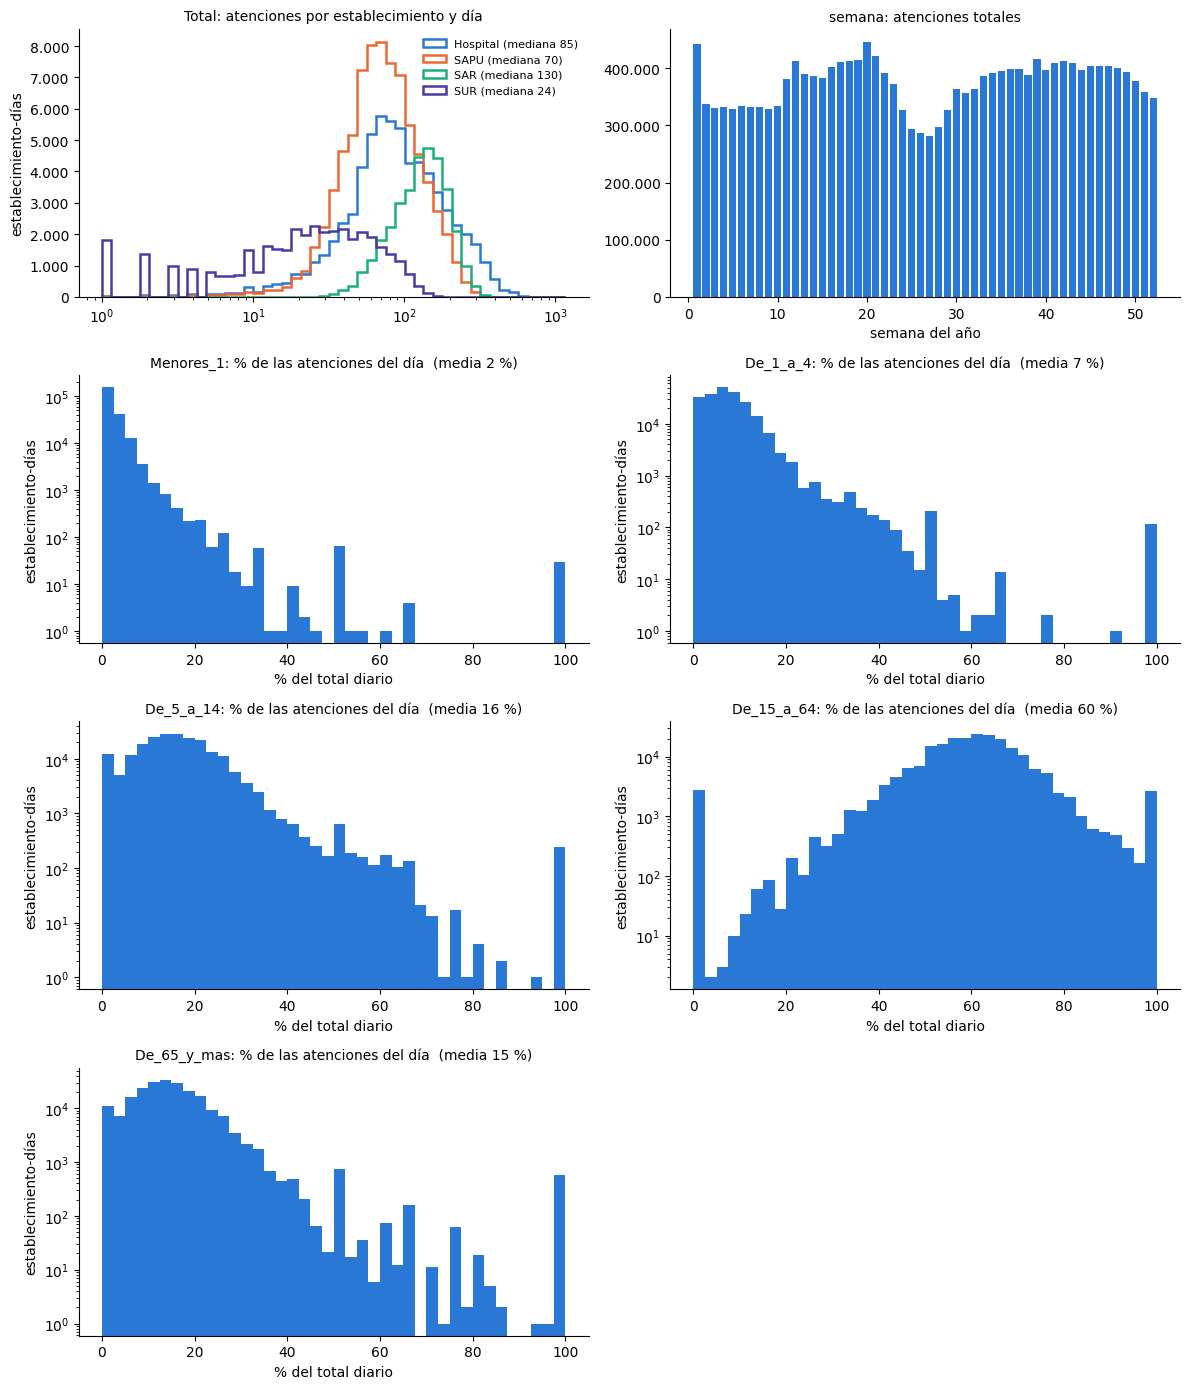

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))

# Total por establecimiento-día, por tipo de establecimiento
ax = axes[0, 0]
bins = np.logspace(0, np.log10(tot["Total"].max()), 50)
for tipo, c in zip(["Hospital", "SAPU", "SAR", "SUR"], ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]):
    v = tot.loc[(tot["GLOSATIPOESTABLECIMIENTO"] == tipo) & (tot["Total"] > 0), "Total"]
    ax.hist(v, bins=bins, histtype="step", linewidth=1.8, color=c, label=f"{tipo} (mediana {v.median():.0f})")
ax.set_xscale("log"); ax.set_ylabel("establecimiento-días")
ax.set_title("Total: atenciones por establecimiento y día", fontsize=10); ax.legend(fontsize=8, frameon=False)
ax.yaxis.set_major_formatter(miles)

# semana
ax = axes[0, 1]
por_sem = tot.groupby("semana")["Total"].sum()
ax.bar(por_sem.index, por_sem.values, color=AZUL)
ax.set_title("semana: atenciones totales", fontsize=10); ax.set_xlabel("semana del año")
ax.yaxis.set_major_formatter(miles)

# edades: % del total del día
tt = tot[tot["Total"] > 0]
for ax, col in zip(axes.flat[2:], EDADES):
    pct = tt[col] / tt["Total"] * 100
    ax.hist(pct, bins=np.linspace(0, 100, 41), color=AZUL)
    ax.set_yscale("log")
    ax.set_title(f"{col}: % de las atenciones del día  (media {pct.mean():.0f} %)", fontsize=10)
    ax.set_xlabel("% del total diario"); ax.set_ylabel("establecimiento-días")
for ax in axes.flat[7:]:
    ax.axis("off")
fig.tight_layout(); plt.show()

## 3. Columnas de texto y códigos: atenciones por categoría

Top 15 por atenciones totales del año.

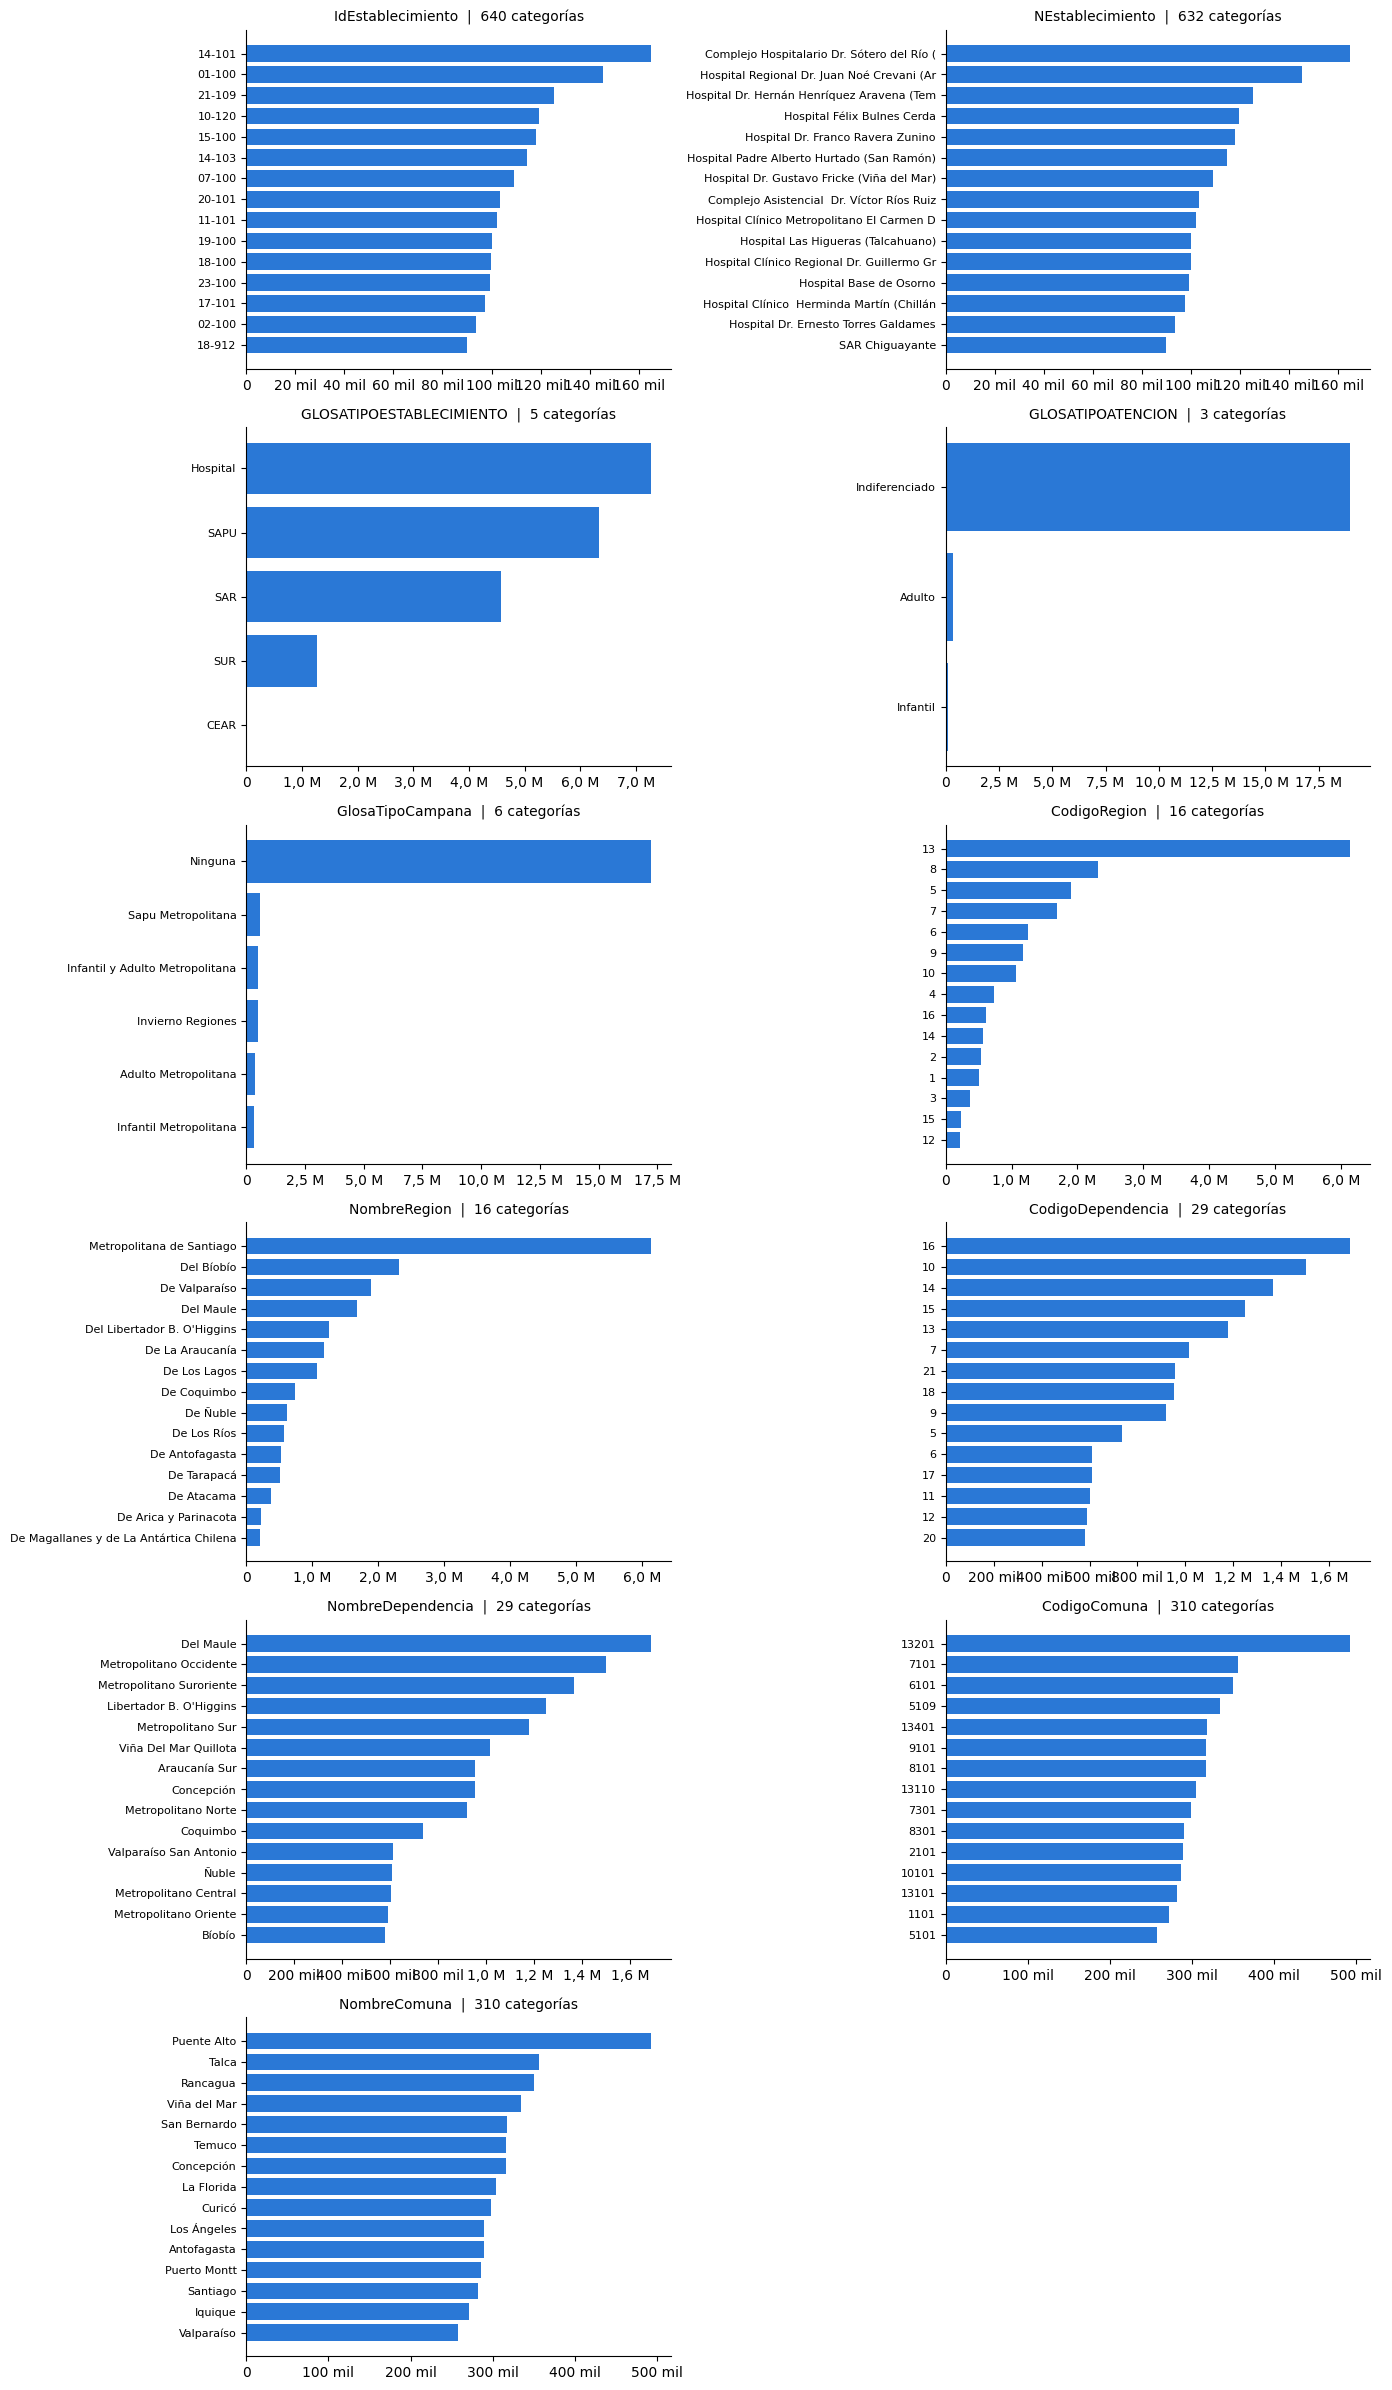

In [16]:
def top_barras(ax, serie, titulo, n=15, etiqueta=lambda x: str(x)[:42]):
    top = serie.sort_values(ascending=False).head(n)[::-1]
    ax.barh([etiqueta(i) for i in top.index], top.values, color=AZUL)
    ax.set_title(f"{titulo}  |  {len(serie):,} categorías".replace(",", "."), fontsize=10)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: corto(v)))
    ax.tick_params(axis="y", labelsize=8)

COLS_LUGAR = ["IdEstablecimiento", "NEstablecimiento", "GLOSATIPOESTABLECIMIENTO", "GLOSATIPOATENCION",
              "GlosaTipoCampana", "CodigoRegion", "NombreRegion", "CodigoDependencia",
              "NombreDependencia", "CodigoComuna", "NombreComuna"]
fig, axes = plt.subplots(6, 2, figsize=(14, 24))
for ax, col in zip(axes.flat, COLS_LUGAR):
    top_barras(ax, tot.groupby(col, observed=True)["Total"].sum(), col)
for ax in axes.flat[len(COLS_LUGAR):]:
    ax.axis("off")
fig.tight_layout(); plt.show()

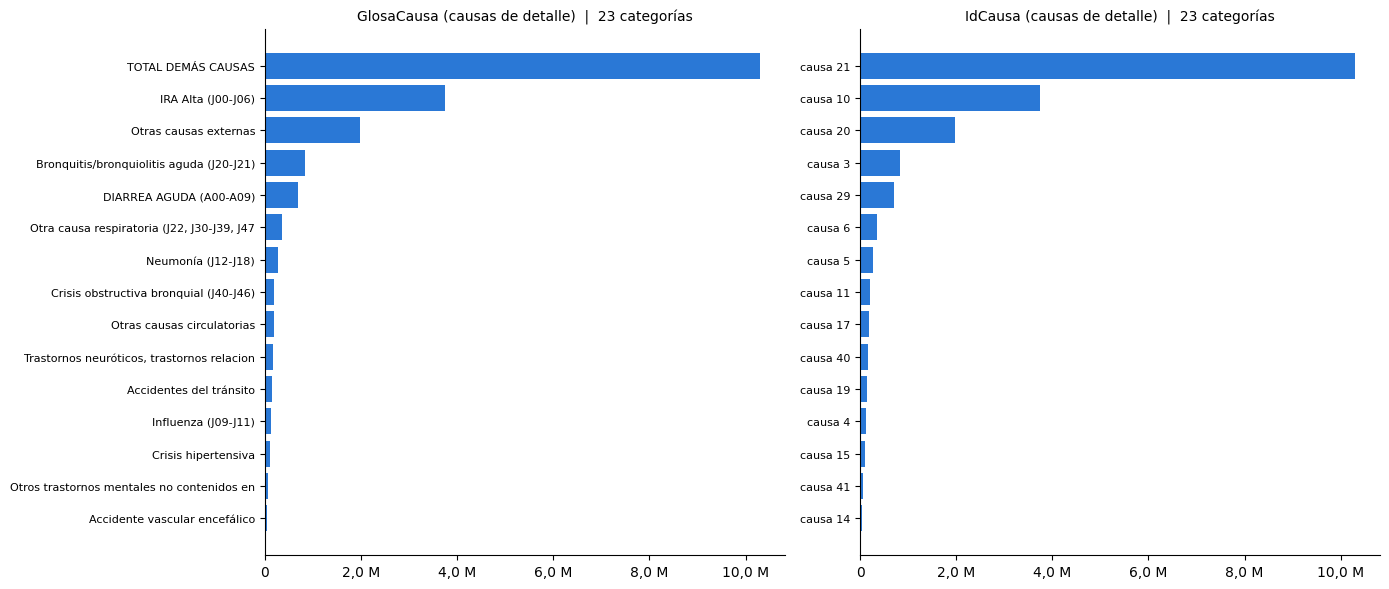

In [17]:
# Causas: IdCausa y GlosaCausa son el mismo dato (código y nombre). Solo causas de detalle.
por_causa = det.groupby(["IdCausa", "GlosaCausa"], observed=True)["Total"].sum()
por_causa = por_causa[por_causa > 0].reset_index()
por_causa["GlosaCausa"] = por_causa["GlosaCausa"].astype(str).str.strip(" -\xa0")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_barras(axes[0], por_causa.set_index("GlosaCausa")["Total"], "GlosaCausa (causas de detalle)", n=15)
top_barras(axes[1], por_causa.set_index("IdCausa")["Total"], "IdCausa (causas de detalle)", n=15, etiqueta=lambda x: f"causa {x}")
fig.tight_layout(); plt.show()

## 4. Fecha

Atenciones por día (total nacional) con promedio móvil de 7 días.

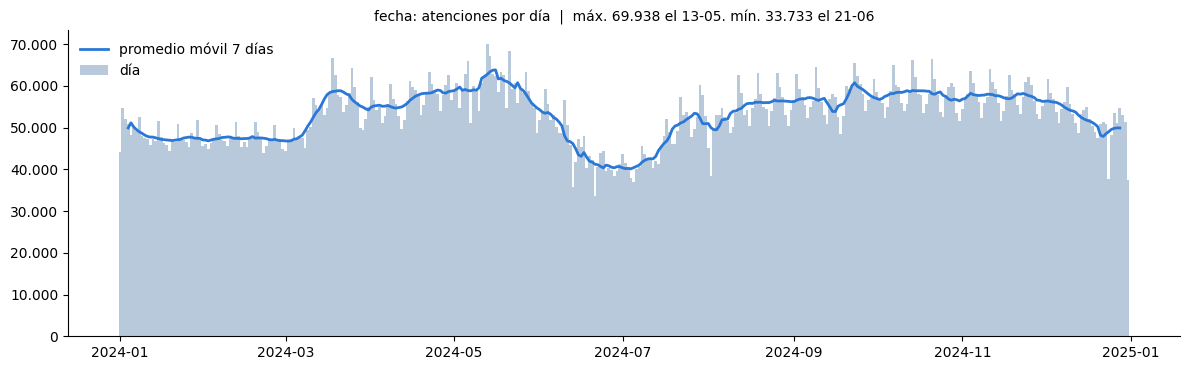

In [18]:
dia = tot.groupby("fecha")["Total"].sum()
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.bar(dia.index, dia.values, width=1, color="#b9c9dc", label="día")
ax.plot(dia.index, dia.rolling(7, center=True).mean(), color=AZUL, linewidth=2, label="promedio móvil 7 días")
ax.set_title(f"fecha: atenciones por día  |  máx. {dia.max():,} el {dia.idxmax():%d-%m}, mín. {dia.min():,} el {dia.idxmin():%d-%m}".replace(",", "."), fontsize=10)
ax.yaxis.set_major_formatter(miles); ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 5. Dónde sí se ven las diferencias

Comparar grupos de causa: la estacionalidad y la edad cambian mucho de un grupo a otro.

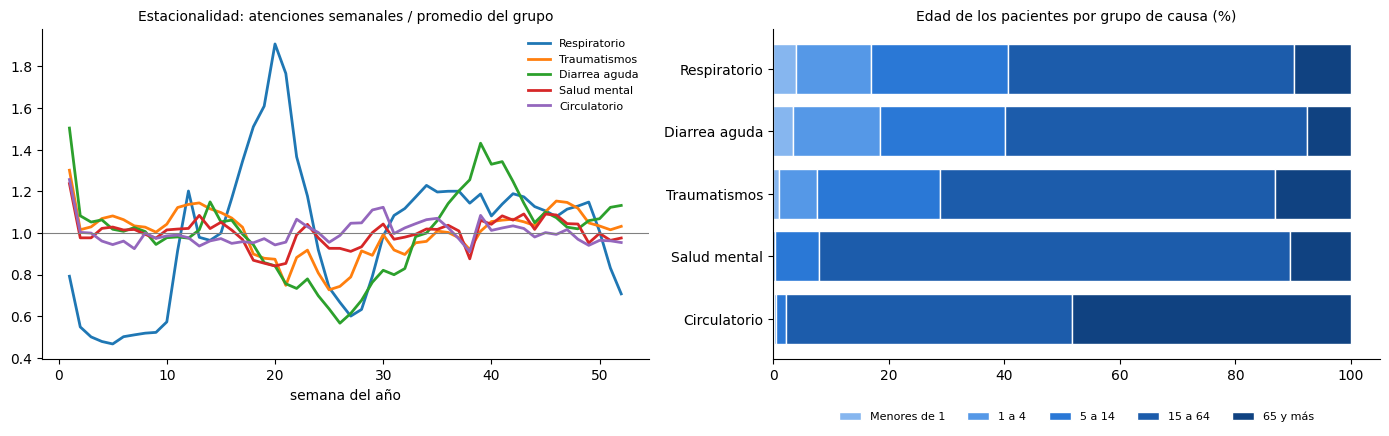

In [19]:
nombre = {i: n for n, ids in GRUPOS.items() for i in ids}
g = df[df["IdCausa"].isin(nombre)].assign(grupo=lambda d: d["IdCausa"].map(nombre))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
semanal = g.pivot_table(index="semana", columns="grupo", values="Total", aggfunc="sum", observed=True)
for col in ["Respiratorio", "Traumatismos", "Diarrea aguda", "Salud mental", "Circulatorio"]:
    axes[0].plot(semanal.index, semanal[col] / semanal[col].mean(), linewidth=2, label=col)
axes[0].axhline(1, color="gray", linewidth=0.8)
axes[0].set_title("Estacionalidad: atenciones semanales / promedio del grupo", fontsize=10)
axes[0].set_xlabel("semana del año"); axes[0].legend(frameon=False, fontsize=8)

orden = ["Respiratorio", "Diarrea aguda", "Traumatismos", "Salud mental", "Circulatorio"]
edad = g.groupby("grupo", observed=True)[EDADES].sum()
edad = edad.div(edad.sum(axis=1), axis=0).loc[orden][::-1] * 100
izq = np.zeros(len(edad))
for col, c in zip(EDADES, ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]):
    axes[1].barh(edad.index, edad[col], left=izq, color=c, label=NOMBRE_EDAD[col], edgecolor="white")
    izq += edad[col].values
axes[1].set_title("Edad de los pacientes por grupo de causa (%)", fontsize=10)
axes[1].legend(frameon=False, fontsize=8, ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.22))
fig.tight_layout(); plt.show()

# Parte 2. Hospital Grant Benavente: de la demanda a los médicos

Objetivo: predecir cuántos médicos se necesitan la próxima semana en la urgencia del Hospital Clínico Regional Dr. Guillermo Grant Benavente (Concepción, `IdEstablecimiento = 18-100`).

```
Atenciones diarias ──► predicción de demanda (con margen) ──► médicos-turno necesarios
                                  ▲
        parámetro de capacidad (pacientes por médico) ── NO está en los datos
```

**Los datos no traen médicos.** El archivo solo tiene atenciones. La conversión a médicos usa un parámetro de capacidad que hay que pedir al hospital o validar con los profesores. Los valores de abajo son **ejemplos**.

In [20]:
HOSP = "18-100"
INICIO_EVAL = pd.Timestamp("2024-10-01")      # calibración: ene-sep | evaluación: oct-dic
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]

# --- Parámetros de capacidad: EJEMPLOS, reemplazar por los reales del hospital ---
PACIENTES_HORA = 3.0     # pacientes que atiende un médico por hora
HORAS_TURNO = 12         # duración de un turno
OCUPACION = 0.80         # fracción del turno dedicada a atender (el resto: papeleo, pausas, etc.)
CAP = PACIENTES_HORA * HORAS_TURNO * OCUPACION
print(f"Capacidad de un médico-turno: {CAP:.1f} pacientes")

h = tot.loc[tot["IdEstablecimiento"].astype(str) == HOSP].set_index("fecha")["Total"].sort_index()
assert len(h) == 366, len(h)
print(f"{h.sum():,} atenciones | mediana diaria {h.median():.0f} | rango {h.min()}-{h.max()}".replace(",", "."))

Capacidad de un médico-turno: 28.8 pacientes
99.881 atenciones | mediana diaria 272 | rango 128-391


## 1. Cómo se comporta la demanda del hospital

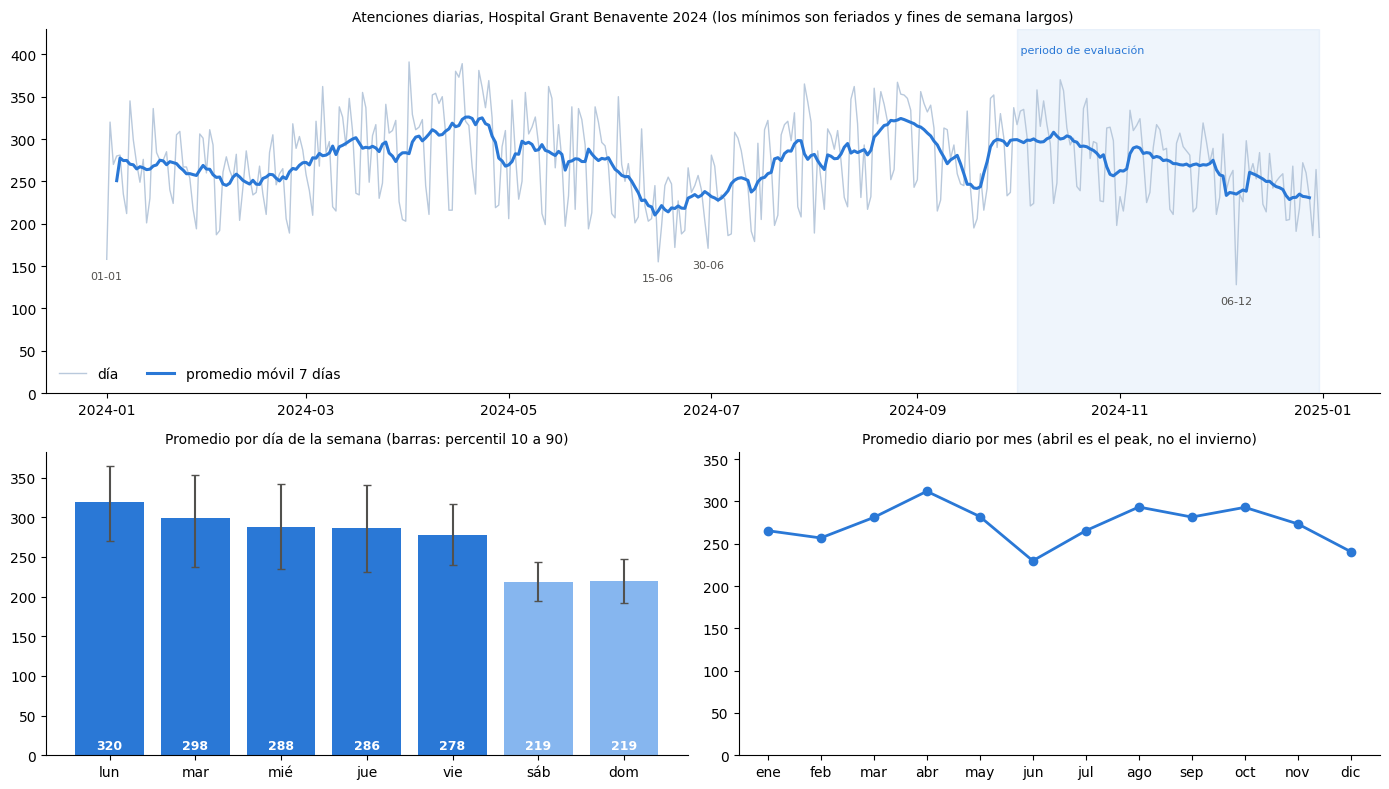

In [21]:
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

# serie diaria
ax = fig.add_subplot(gs[0, :])
ax.axvspan(INICIO_EVAL, h.index[-1], color="#2a78d6", alpha=0.07)
ax.text(INICIO_EVAL, h.max() * 1.02, " periodo de evaluación", fontsize=8, color="#2a78d6", va="bottom")
ax.plot(h.index, h.values, color="#b9c9dc", linewidth=1, label="día")
ax.plot(h.index, h.rolling(7, center=True).mean(), color=AZUL, linewidth=2.2, label="promedio móvil 7 días")
for fecha in h.nsmallest(4).index:
    ax.annotate(f"{fecha:%d-%m}", (fecha, h[fecha]), xytext=(0, -14), textcoords="offset points",
                ha="center", fontsize=8, color="#52514e")
ax.set_title("Atenciones diarias, Hospital Grant Benavente 2024 (los mínimos son feriados y fines de semana largos)", fontsize=10)
ax.set_ylim(0, h.max() * 1.1); ax.legend(frameon=False, loc="lower left", ncol=2)

# perfil por día de la semana
ax = fig.add_subplot(gs[1, 0])
g = h.groupby(h.index.dayofweek)
media, p10, p90 = g.mean(), g.quantile(.1), g.quantile(.9)
colores = [AZUL] * 5 + ["#86b6ef"] * 2
ax.bar(DIAS, media, color=colores, yerr=[media - p10, p90 - media], capsize=3, ecolor="#52514e")
for i, v in enumerate(media):
    ax.text(i, 8, f"{v:.0f}", ha="center", color="white", fontsize=9, fontweight="bold")
ax.set_title("Promedio por día de la semana (barras: percentil 10 a 90)", fontsize=10)

# perfil por mes
ax = fig.add_subplot(gs[1, 1])
mes = h.groupby(h.index.month).mean()
ax.plot(mes.index, mes.values, marker="o", color=AZUL, linewidth=2)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"])
ax.set_ylim(0, mes.max() * 1.15)
ax.set_title("Promedio diario por mes (abril es el peak, no el invierno)", fontsize=10)
fig.tight_layout(); plt.show()

## 2. Meta a vencer: repetir lo de la semana pasada

La regla más simple es predecir cada día con el mismo día de la semana anterior. Cualquier modelo de ML tiene que mejorar esto para justificarse.

Como en urgencia faltar médicos cuesta más que que sobren, la predicción se corrige con un **margen**: se le suma el percentil 80 o 90 del error histórico de la regla. Los márgenes se calibran con enero a septiembre y se evalúan con octubre a diciembre, para no medir con los mismos datos.

In [22]:
base = h.shift(7)                                     # predicción ingenua
err = (h - base).dropna()
calib = err[err.index < INICIO_EVAL]
ev = h[h.index >= INICIO_EVAL]
MARGEN = {"Punto": 0.0, "P80": max(calib.quantile(.8), 0), "P90": max(calib.quantile(.9), 0)}

print(f"Error absoluto medio de la regla en oct-dic: {(ev - base[ev.index]).abs().mean():.1f} pacientes/día "
      f"({((ev - base[ev.index]).abs() / ev).mean() * 100:.1f} %)")
print({k: round(v, 1) for k, v in MARGEN.items()})

def evaluar(cap, margen, periodo=ev):
    """Compara médicos-turno asignados (con la predicción) y necesarios (con la demanda real)."""
    asignados = np.ceil((base[periodo.index] + margen) / cap)
    necesarios = np.ceil(periodo / cap)
    return pd.Series({
        "días con déficit (%)": (asignados < necesarios).mean() * 100,
        "médicos-turno de sobra por semana": np.clip(asignados - necesarios, 0, None).sum() / len(periodo) * 7,
        "médicos-turno promedio por día": asignados.mean(),
    })

resumen = pd.DataFrame({k: evaluar(CAP, m) for k, m in MARGEN.items()}).T.round(1)
resumen

Error absoluto medio de la regla en oct-dic: 22.8 pacientes/día (9.3 %)
{'Punto': 0.0, 'P80': np.float64(31.0), 'P90': np.float64(48.4)}


,días con déficit (%),médicos-turno de sobra por semana,médicos-turno promedio por día
Punto,23.9,3.6,10.0
P80,2.2,9.4,11.1
P90,2.2,13.5,11.7


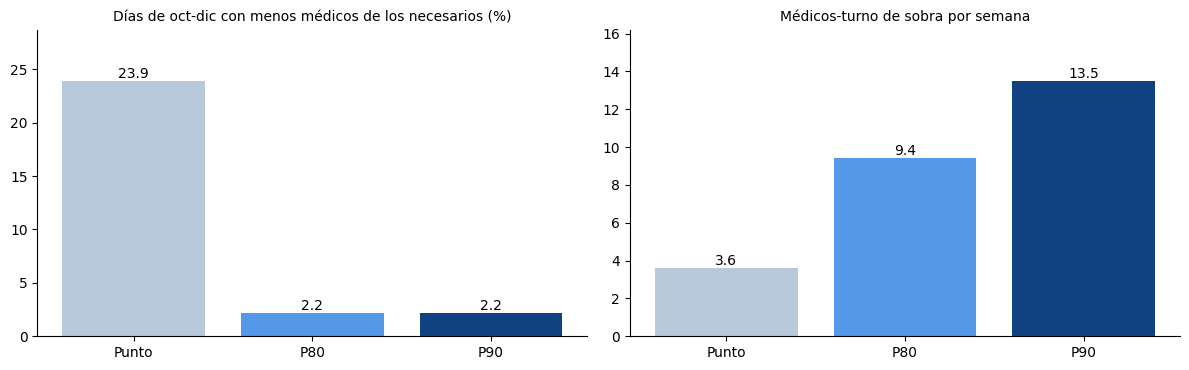

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
colores = ["#b9c9dc", "#5598e7", "#104281"]
axes[0].bar(resumen.index, resumen["días con déficit (%)"], color=colores)
axes[0].set_title("Días de oct-dic con menos médicos de los necesarios (%)", fontsize=10)
axes[1].bar(resumen.index, resumen["médicos-turno de sobra por semana"], color=colores)
axes[1].set_title("Médicos-turno de sobra por semana", fontsize=10)
for ax, col in zip(axes, ["días con déficit (%)", "médicos-turno de sobra por semana"]):
    for i, v in enumerate(resumen[col]):
        ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=10)
    ax.set_ylim(0, resumen[col].max() * 1.2)
fig.tight_layout(); plt.show()

## 3. Una semana de ejemplo: lo que vería la jefatura el lunes

Arriba, la demanda esperada con su margen frente a lo que ocurrió. Abajo, los médicos-turno que se asignarían con el margen P90 frente a los que realmente se necesitaban.

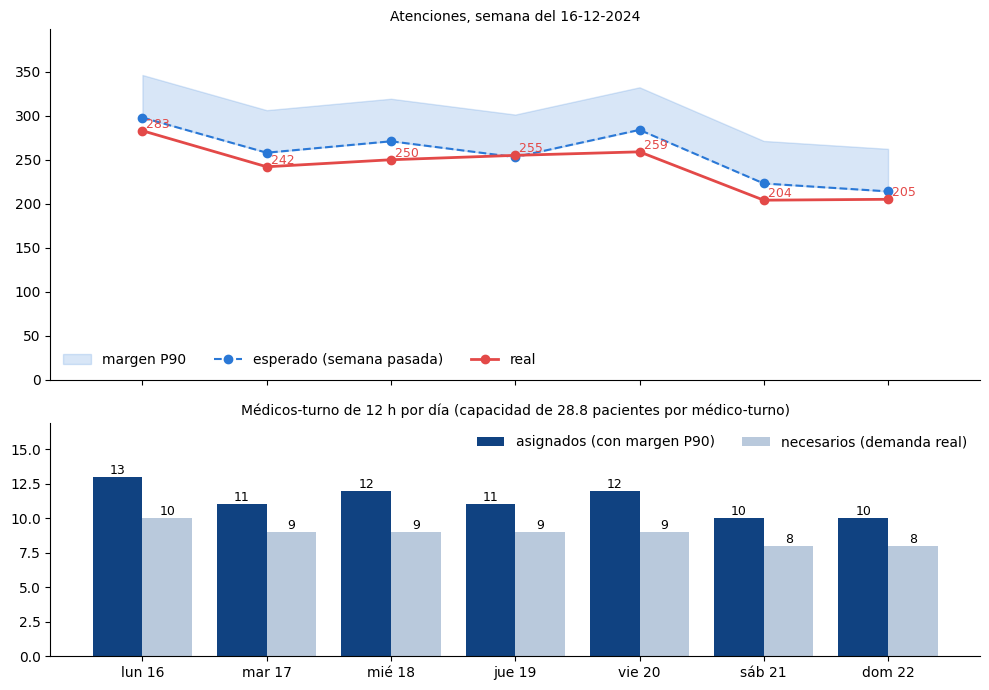

Semana: 79 médicos-turno asignados vs 62 necesarios


In [24]:
LUNES = pd.Timestamp("2024-12-16")                    # cambiar para ver otra semana
sem = pd.date_range(LUNES, periods=7)
real, esperado = h[sem], base[sem]
asig = np.ceil((esperado + MARGEN["P90"]) / CAP)
nec = np.ceil(real / CAP)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [1.5, 1]})
x = np.arange(7)
a1.fill_between(x, esperado, esperado + MARGEN["P90"], color="#2a78d6", alpha=0.18, label="margen P90")
a1.plot(x, esperado, color=AZUL, linestyle="--", marker="o", label="esperado (semana pasada)")
a1.plot(x, real, color="#e34948", marker="o", linewidth=2, label="real")
for i in range(7):
    a1.text(i, real.iloc[i], f" {real.iloc[i]}", ha="left", va="bottom", fontsize=9, color="#e34948")
a1.set_ylim(0, max(real.max(), (esperado + MARGEN['P90']).max()) * 1.15)
a1.set_title(f"Atenciones, semana del {LUNES:%d-%m-%Y}", fontsize=10); a1.legend(frameon=False, ncol=3, loc="lower left")

a2.bar(x - 0.2, asig, width=0.4, color="#104281", label="asignados (con margen P90)")
a2.bar(x + 0.2, nec, width=0.4, color="#b9c9dc", label="necesarios (demanda real)")
for i in range(7):
    a2.text(i - 0.2, asig.iloc[i], f"{asig.iloc[i]:.0f}", ha="center", va="bottom", fontsize=9)
    a2.text(i + 0.2, nec.iloc[i], f"{nec.iloc[i]:.0f}", ha="center", va="bottom", fontsize=9)
a2.set_xticks(x); a2.set_xticklabels([f"{DIAS[i]} {d:%d}" for i, d in enumerate(sem)])
a2.set_title(f"Médicos-turno de {HORAS_TURNO} h por día (capacidad de {CAP:.1f} pacientes por médico-turno)", fontsize=10)
a2.legend(frameon=False, ncol=2, loc="upper right"); a2.set_ylim(0, max(asig.max(), nec.max()) * 1.3)
fig.tight_layout(); plt.show()
print(f"Semana: {asig.sum():.0f} médicos-turno asignados vs {nec.sum():.0f} necesarios")

## 4. Sensibilidad al parámetro de capacidad

Como la capacidad no sale de los datos, se muestra qué pasa con distintos valores. Cada celda es una combinación de pacientes por hora y margen.

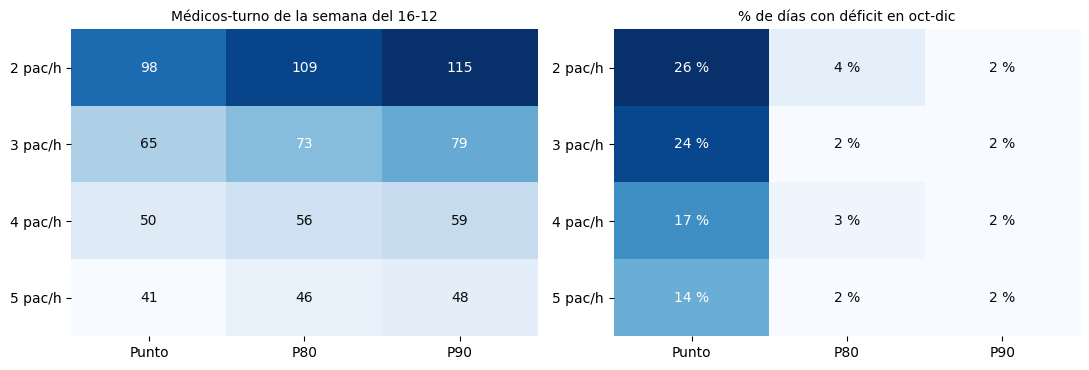

In [25]:
pph_vals = [2, 3, 4, 5]
filas_med, filas_def = {}, {}
for pph in pph_vals:
    cap = pph * HORAS_TURNO * OCUPACION
    filas_med[f"{pph} pac/h"] = {k: np.ceil((base[sem] + m) / cap).sum() for k, m in MARGEN.items()}
    filas_def[f"{pph} pac/h"] = {k: evaluar(cap, m)["días con déficit (%)"] for k, m in MARGEN.items()}
M1, M2 = pd.DataFrame(filas_med).T, pd.DataFrame(filas_def).T

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, M, titulo, fmt in [(axes[0], M1, f"Médicos-turno de la semana del {LUNES:%d-%m}", "{:.0f}"),
                           (axes[1], M2, "% de días con déficit en oct-dic", "{:.0f} %")]:
    im = ax.imshow(M.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(M.shape[1])); ax.set_xticklabels(M.columns)
    ax.set_yticks(range(M.shape[0])); ax.set_yticklabels(M.index)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.values[i, j]
            ax.text(j, i, fmt.format(v), ha="center", va="center",
                    color="white" if v > M.values.mean() else "#0b0b0b", fontsize=10)
    ax.set_title(titulo, fontsize=10)
    for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout(); plt.show()

## 5. Próximos pasos

1. Reemplazar el parámetro de capacidad por el real del hospital y validarlo con los profesores.
2. Cambiar la regla "semana pasada" por un modelo de ML (calendario, feriados, retardos) y comprobar que baja el error frente a esta línea base.
3. Conseguir más años de datos: con 2024 solo hay un invierno para validar.
4. Decidir el percentil de margen (P80 o P90) con la jefatura: es una decisión de negocio, no estadística.